# McCall Model

Pablo Winant

### Job-Search Model

- When unemployed in date, a job-seeker
  - consumes unemployment benefit $c_t = \underline{c}$
  - receives in every date $t$ a job offer $w_t$
    - $w_t$ is i.i.d.,
    - takes values $w_1, w_2, w_3$ with probabilities $p_1, p_2, p_3$
  - if job-seeker accepts, becomes employed at rate $w_t$ in the next
    period
  - else he stays unemployed
- When employed at rate $w$
  - worker consumes salary $c_t = w$
  - with small probability $\lambda>0$ looses his job:
    - starts next period unemployed
  - otherwise stays employed at same rate
- Objective: $\max E_0 \left\{ \sum \beta^t \log(c_t) \right\}$

1.  **What are the states, the controls, the reward of this problem ?
    Write down the Bellman equation.**

In [ ]:
#  your code here

1.  **Define a named tuple for the model.**

In [3]:
model = (;
    λ=0.05,
    β=0.9, # yearly discount
    w=[0.9, 1.0, 1.1],
    p=ones(3)/3,
    cbar=0.5, 
)

(λ = 0.05, β = 0.9, w = [0.9, 1.0, 1.1], p = [0.3333333333333333, 0.3333333333333333, 0.3333333333333333], cbar = 0.5)

1.  **Define a function
    `value_update(V_U::Vector{Float64}, V_E::Vector{Float64}, x::Vector{Bool}, p::Parameters)::Tuple{Vector, Vector}`,
    which takes in value functions tomorrow and a policy vector and
    return updated values for today.**

In [4]:
V_U_0 = zeros(3)
V_E_0 = zeros(3)
x_0 = [false, false, false]

function value_update(V_U, V_E, x, model)

    (;cbar, λ, β, w, p) = model

    new_V_U = zeros(3)
    new_V_E = zeros(3)

    # expected value of being unemployed without knowing the future offer
    EVU = sum(p[i]*V_U[i] for i=1:3)

    # unemployed
    for i=1:3
        # EVU = p'*V_U
        if x[i]
            # if reject
            new_V_U[i] = log(cbar) + β*EVU
        else
            # if accept
            new_V_U[i] = log(cbar) + β*V_E[i]
        end
    end

    # employed
    for i=1:3
        
        new_V_E[i] = log(w[i]) + (1-λ)*β*V_E[i] + λ*β*EVU
    end

    return new_V_U, new_V_E
end

value_update(V_U_0, V_E_0, x_0, model)

([-0.6931471805599453, -0.6931471805599453, -0.6931471805599453], [-0.10536051565782628, 0.0, 0.09531017980432493])

1.  **Define a function
    `policy_eval(x::Vector{Bool}, p::Parameter)::Tuple{Vector, Vector}`
    which takes in a policy vector and returns the value(s) of following
    this policies forever. You can add relevant arguments to the
    function.**

In [5]:
using LinearAlgebra: norm

In [18]:
function policy_eval(x, model; T=1000, τ=1e-8)
    
    V_U_0 = zeros(3)
    V_E_0 = zeros(3)
    
    η_0 = NaN
    for t=1:T
        V_U_1, V_E_1 = value_update(V_U_0, V_E_0, x, model)
        η = norm( [V_U_1, V_E_1] .- [V_U_0, V_E_0])
        λ = η/η_0
        η_0 = η
        # @show (t, η, λ)
        if η<τ
            break
        end
        V_U_0, V_E_0 = V_U_1, V_E_1
    end

    return V_U_0, V_E_0
end

policy_eval(x_0, model)

([-1.623803790848331, -0.9698419695587606, -0.3782615432186312], [-1.0340629047854952, -0.3074386589025771, 0.34987292592487074])

1.  **Define a function
    `bellman_step(V_E::Vector, V_U::Vector, p::Parameters)::Tuple{Vector, Vector, Vector}`
    which returns updated values, together with improved policy rules.**

In [7]:
zeros(Bool, 3)

3-element Vector{Bool}:
 0
 0
 0

In [14]:
function bellman_step(V_U, V_E, model)

    (;cbar, λ, β, w, p) = model

    new_V_U = zeros(3)
    new_V_E = zeros(3)

    new_x = zeros(Bool, 3)

    # expected value of being unemployed without knowing the future offer
    EVU = sum(p[i]*V_U[i] for i=1:3)

    # unemployed
    for i=1:3
        # EVU = p'*V_U
        # test both choices
        # if reject
        V_reject = log(cbar) + β*EVU
        V_accept = log(cbar) + β*V_E[i]
        if V_accept > V_reject
            new_V_U[i] = V_accept
            new_x[i] = true
        else # V_accept <= V_reject
            new_V_U[i] = V_reject
            new_x[i] = false
        end

    end

    # employed
    for i=1:3
        
        new_V_E[i] = log(w[i]) + (1-λ)*β*V_E[i] + λ*β*EVU
    end

    return new_V_U, new_V_E, new_x
end

bellman_step(V_U_0, V_E_0, model)

([-0.6931471805599453, -0.6931471805599453, -0.6931471805599453], [-0.10536051565782628, 0.0, 0.09531017980432493], Bool[0, 0, 0])

1.  **Implement Value Function Iteration**

In [33]:
# we want to iterate on bellman_step to find a fixed

# We can reuse the code from value_update
# DIFF: policy_eval becomes vfi : no need for x argument
function vfi(model; T=1000, τ=1e-10)
    
    V_U_0 = zeros(3)
    V_E_0 = zeros(3)
    
    local x # to access x outside of the loop
    η_0 = NaN
    for t=1:T
        # value_update becomes bellman_step: returns x
        V_U_1, V_E_1, x  = bellman_step(V_U_0, V_E_0,  model)
        η = norm( [V_U_1, V_E_1] .- [V_U_0, V_E_0])
        λ = η/η_0
        η_0 = η
        # @show (t, η, λ, x)
        if η<τ
            break
        end
        V_U_0, V_E_0 = V_U_1, V_E_1
    end

    return V_U_0, V_E_0, x
end


vfi (generic function with 1 method)

In [26]:
result = vfi(model)
result[3]

(t, η, λ, x) = (1, 1.208943303215093, NaN, Bool[0, 0, 0])
(t, η, λ, x) = (2, 0.18590374068089768, 0.1537737462017456, Bool[1, 1, 1])
(t, η, λ, x) = (3, 0.16759036136579744, 0.9014899902066252, Bool[1, 1, 1])
(t, η, λ, x) = (4, 0.14409682402816418, 0.8598157009378707, Bool[1, 1, 1])
(t, η, λ, x) = (5, 0.12456251750964775, 0.8644362452103845, Bool[1, 1, 1])
(t, η, λ, x) = (6, 0.10774709002397113, 0.8650041134214054, Bool[1, 1, 1])
(t, η, λ, x) = (7, 0.09329138586429168, 0.8658367093119322, Bool[1, 1, 1])
(t, η, λ, x) = (8, 0.08085585077337948, 0.8667022150469302, Bool[1, 1, 1])
(t, η, λ, x) = (9, 0.07015150893870908, 0.8676120313832053, Bool[1, 1, 1])
(t, η, λ, x) = (10, 0.060931055972414, 0.8685637257731558, Bool[1, 1, 1])
(t, η, λ, x) = (11, 0.05298290181068721, 0.8695549578965898, Bool[1, 1, 1])
(t, η, λ, x) = (12, 0.04612599856416276, 0.8705827160802782, Bool[1, 1, 1])
(t, η, λ, x) = (13, 0.04020542076978306, 0.8716433686276952, Bool[1, 1, 1])
(t, η, λ, x) = (14, 0.035088585123295185

3-element Vector{Bool}:
 0
 1
 1

1.  **Implement Policy Iteration and compare rates of convergence.**

In [29]:
# we want to iterate on bellman_step to find a fixed

# We can recycle the code from vfi

function policy_iteration(model; T=1000, τ=1e-8)
    
    V_U_0 = zeros(3)
    V_E_0 = zeros(3)
    
    local x # to access x outside of the loop
    
    η_0 = NaN
    for t=1:T
        # DIFF: change the output names (we don't reuse the values)
        V_U_1_t, V_E_1_t, x  = bellman_step(V_U_0, V_E_0,  model)
        V_U_1, V_E_1 = policy_eval(x, model)
        η = norm( [V_U_1, V_E_1] .- [V_U_0, V_E_0])
        λ = η/η_0
        η_0 = η
        # @show (t, η, λ, x)
        if η<τ
            break
        end
        V_U_0, V_E_0 = V_U_1, V_E_1
    end

    return V_U_0, V_E_0, x
end

policy_iteration (generic function with 1 method)

In [30]:
policy_iteration(model) ## bug 

([-6.931471765376201, -6.931471765376201, -6.931471765376201], [-2.8777706281225095, -2.151146382206878, -1.4938347973498374], Bool[1, 1, 1])

1.  **Discuss the Effects of the Parameters**

In [ ]:
vfi(model)[3]
# what could make me reject the middle offer ?

3-element Vector{Bool}:
 0
 1
 1

In [35]:
# increase unemployment benefits
model.w

3-element Vector{Float64}:
 0.9
 1.0
 1.1

In [51]:
using Plots

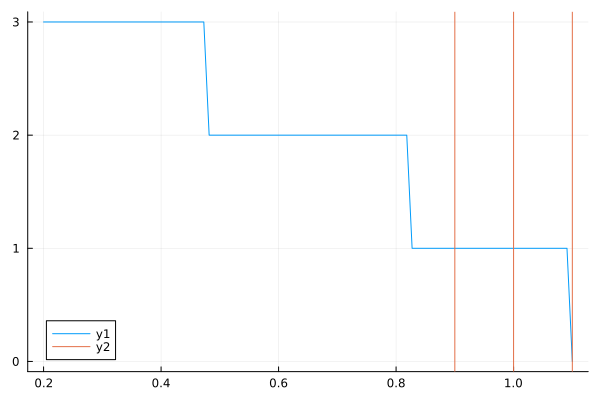

In [59]:
vec = range(start=0.2, stop=1.1; length=100)
accepts = [
    sum(
        vfi(
            merge(
                model,
                (;cbar=cbar)
            )
        )[3]
    ) for cbar in vec]
plot(vec, accepts)
vline!([0.9, 1.0, 1.1])

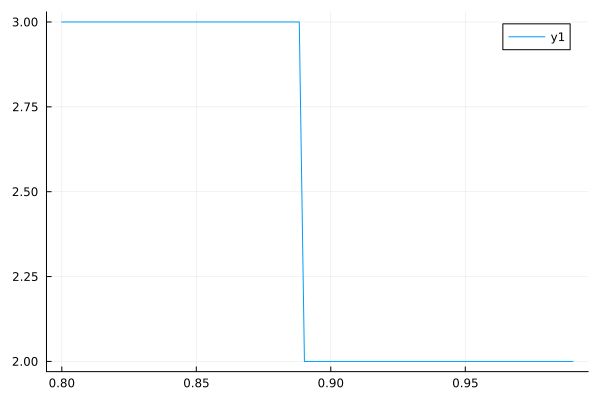

In [64]:
vec = range(start=0.8, stop=0.990; length=100)
accepts = [
    sum(
        vfi(
            merge(
                model,
                (;β=β)
            )
        )[3]
    ) for β in vec]
plot(vec, accepts)
# vline!([0.9, 1.0, 1.1])



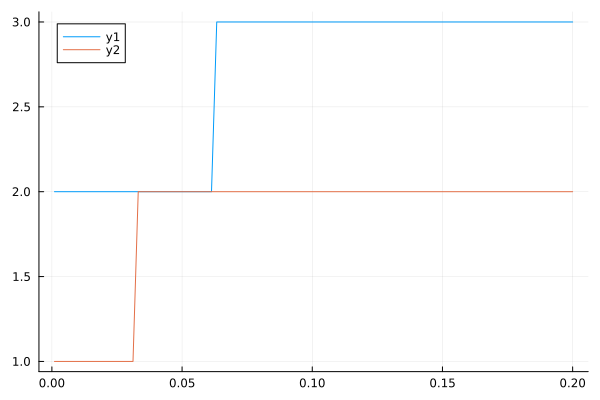

In [67]:
vec = range(start=0.001, stop=0.2; length=100)
accepts = [
    sum(
        vfi(
            merge(
                model,
                (;λ)
            )
        )[3]
    ) for λ in vec]
plot(vec, accepts)

vec = range(start=0.001, stop=0.2; length=100)
accepts = [
    sum(
        vfi(
            merge(
                model,
                (;λ=λ, cbar=0.8)
            )
        )[3]
    ) for λ in vec]
plot!(vec, accepts)
# vline!([0.9, 1.0, 1.1])